[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github//incubodac/GradCamTP/blob/main/GradCam_fig1.ipynb)

### Datos

In [1]:
!wget https://raw.githubusercontent.com/incubodac/GradCamTP/main/imgs/cat_dog.jpg -O cat_dog.jpg

--2025-10-03 22:28:57--  https://raw.githubusercontent.com/incubodac/GradCamTP/main/imgs/cat_dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3529440 (3.4M) [image/jpeg]
Saving to: ‘cat_dog.jpg’

cat_dog.jpg         100%[===================>]   3.37M  --.-KB/s    in 0.009s  

2025-10-03 22:28:57 (391 MB/s) - ‘cat_dog.jpg’ saved [3529440/3529440]



In [2]:
# %%capture
# Install required packages
import subprocess
import sys

packages = [
    "grad-cam",
    # "torch",
    # "torchvision",
    # "matplotlib",
    # "numpy",
    # "opencv-python",
    # "Pillow"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packages installed successfully!")

All packages installed successfully!


In [3]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import requests
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO

# Function to load images directly from URLs
def load_image_from_url(url, transform=None):
    """Load image directly from URL"""
    try:
        response = requests.get(url)
        image = Image.open(BytesIO(response.content)).convert('RGB')
        if transform:
            image = transform(image)
        return image
    except Exception as e:
        print(f"Error loading image from {url}: {e}")
        return None

# image preprocessing for ResNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# free stock images
test_images = {
    'cat': 'https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400',
    'dog': 'https://images.unsplash.com/photo-1552053831-71594a27632d?w=400',
    'car': 'https://images.unsplash.com/photo-1494976388531-d1058494cdd8?w=400',
    'bird': 'https://images.unsplash.com/photo-1444464666168-49d633b86797?w=400',
    'chita': 'https://images.unsplash.com/photo-1551969014-7d2c4cddf0b6?w=400',
    'airplane': 'https://images.unsplash.com/photo-1436491865332-7a61a109cc05?w=400',
    'ship': 'https://images.unsplash.com/photo-1544551763-46a013bb70d5?w=400'
}

def get_sample_images():
    """Get sample images for testing"""
    images = {}

    print("Loading test images...")
    for name, url in test_images.items():
        print(f"Loading {name}...")
        # Load original image for display
        try:
            response = requests.get(url)
            original_img = Image.open(BytesIO(response.content)).convert('RGB')
            # Load preprocessed image for model
            preprocessed_img = load_image_from_url(url, preprocess)

            if preprocessed_img is not None:
                images[name] = {
                    'original': original_img,
                    'tensor': preprocessed_img.unsqueeze(0),  # Add batch dimension
                    'url': url
                }
                print(f"✓ {name} loaded successfully")
            else:
                print(f"✗ Failed to load {name}")
        except Exception as e:
            print(f"✗ Error loading {name}: {e}")

    return images

# Load all test images
sample_images = get_sample_images()

print(f"Loaded {len(sample_images)} test images")


Loading test images...
Loading cat...
✓ cat loaded successfully
Loading dog...
✓ dog loaded successfully
Loading car...
✓ car loaded successfully
Loading bird...
✓ bird loaded successfully
Loading chita...
✓ chita loaded successfully
Loading airplane...
✓ airplane loaded successfully
Loading ship...
✓ ship loaded successfully
Loaded 7 test images


In [4]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import resnet50

import torchvision
from PIL import Image
import numpy as np

model = resnet50(pretrained=True)
target_layers = [model.layer4[-1]]
# open an image file
image = sample_images['cat']['original']
image = image.convert("RGB")
image = image.resize((224, 224))

# image to numpy array and normalize to [0, 1]
rgb_img = np.float32(image) / 255

input_tensor = torchvision.transforms.ToTensor()(image).unsqueeze(0)

# target layer
targets = [ClassifierOutputTarget(246)]

with GradCAM(model=model, target_layers=target_layers) as cam:
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  grayscale_cam = grayscale_cam[0, :]
  visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
  model_outputs = cam.outputs

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


In [5]:
# explore imagenet classes
import requests
import torch.nn.functional as F

def get_imagenet_classes():
    try:
        url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
        response = requests.get(url)
        classes = response.text.strip().split('\n')
        return classes
    except:
        return [f"class_{i}" for i in range(1000)]

imagenet_classes = get_imagenet_classes()

# classes to visualize
interesting_classes = [
    282,  # tiger cat
    285,  # Egyptian cat
    166,  # tabby cat
    404,  # airliner
    817,  # sports car
    130   # flamingo
]

# check if the classes names are correct
for idx in interesting_classes:
    print(f"{idx}: {imagenet_classes[idx]}")



282: tiger cat
285: Egyptian cat
166: Walker hound
404: airliner
817: sports car
130: flamingo


Creating improved 7x7 GradCAM visualization grid...
Classes used: ['tiger cat', 'Egyptian cat', 'Walker hound', 'airliner', 'sports car', 'flamingo']
Error saving figure: [Errno 2] No such file or directory: '/figures/gradcam_resnet50.png'


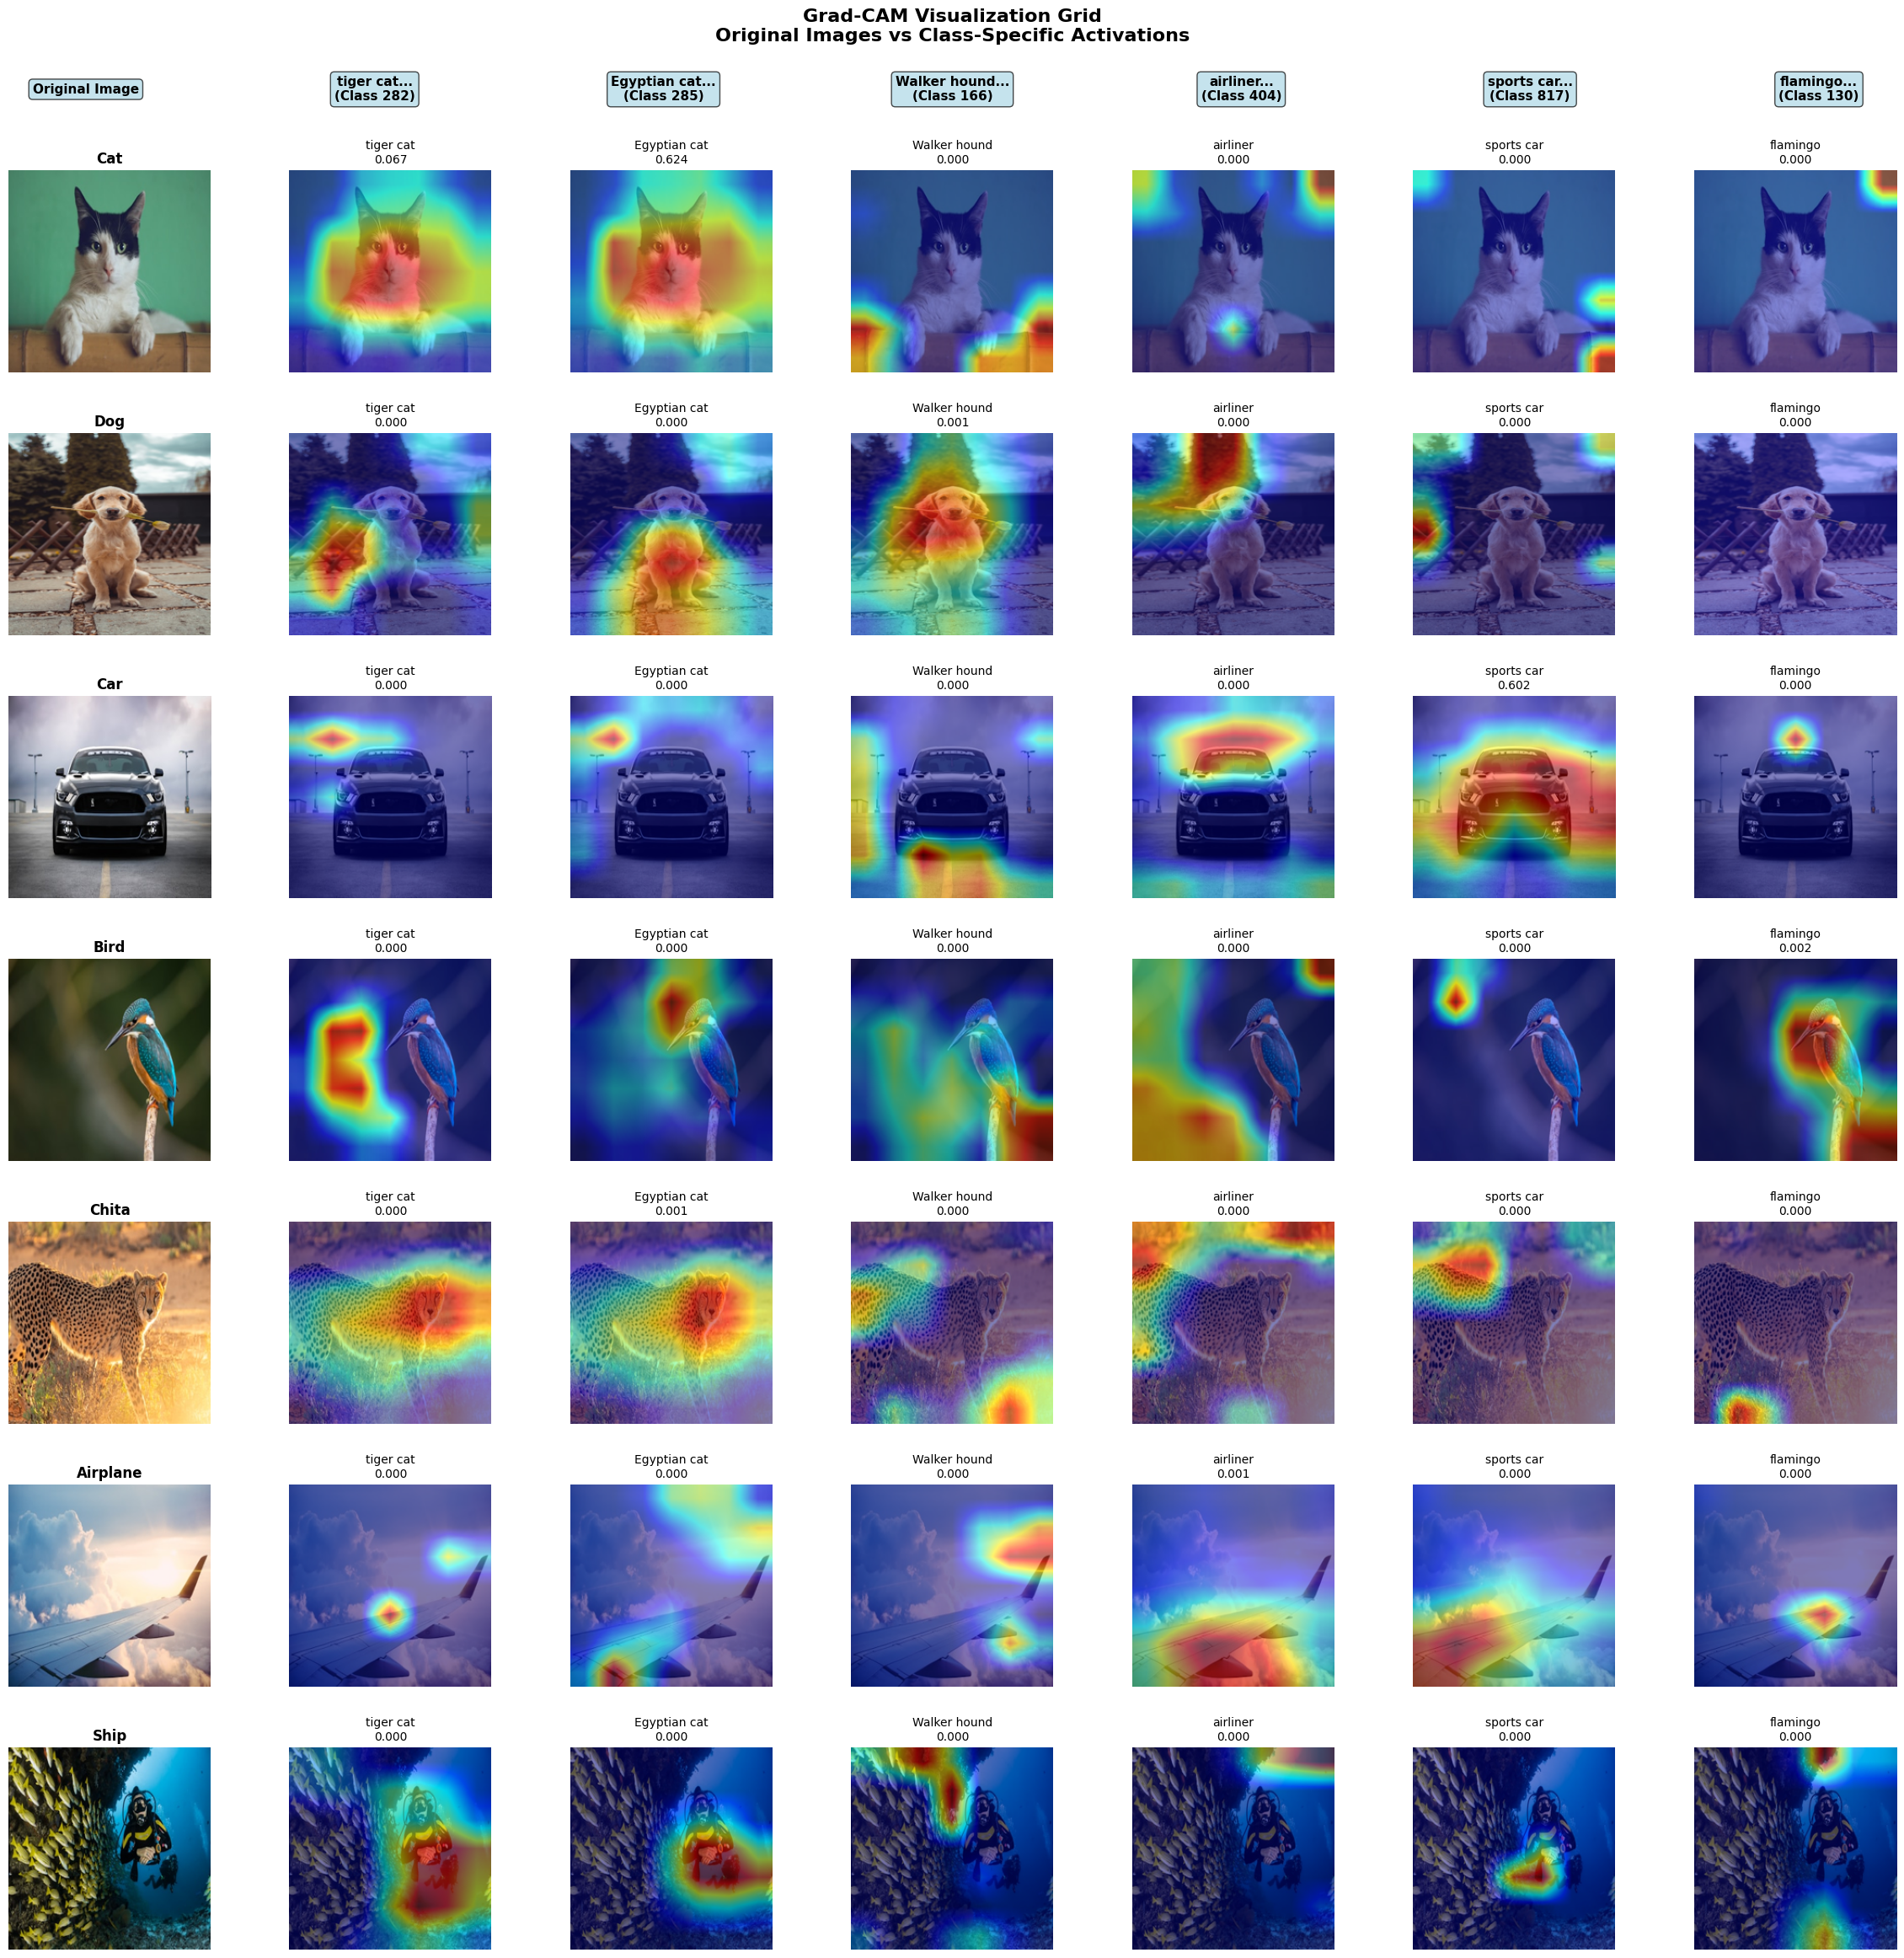

In [8]:
def create_improved_gradcam_grid(sample_images, interesting_classes):
    """Create a 7x7 grid with improved layout and spacing"""
    image_names = list(sample_images.keys())[:7]
    fig, axes = plt.subplots(7, 7, figsize=(24, 24))

    fig.suptitle('Grad-CAM Visualization Grid\nOriginal Images vs Class-Specific Activations',
                 fontsize=16, fontweight='bold', y=0.98)

    for row, image_name in enumerate(image_names):
        if image_name not in sample_images:
            continue

        image_data = sample_images[image_name]
        original_img = image_data['original']
        input_tensor = image_data['tensor']

        display_img = original_img.resize((224, 224))
        rgb_img = np.float32(display_img) / 255

        axes[row, 0].imshow(display_img)
        axes[row, 0].set_title(f'{image_name.capitalize()}', fontsize=12, fontweight='bold')
        axes[row, 0].axis('off')

        for spine in axes[row, 0].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_color('black')

        for col, class_idx in enumerate(interesting_classes[:6], 1):
            try:
                targets = [ClassifierOutputTarget(class_idx)]

                with GradCAM(model=model, target_layers=target_layers) as cam:
                    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
                    grayscale_cam = grayscale_cam[0, :]

                    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

                    model_output = cam.outputs
                    probs = F.softmax(model_output, dim=1)
                    class_prob = probs[0, class_idx].item()

                axes[row, col].imshow(visualization)
                class_name = imagenet_classes[class_idx]
                if len(class_name) > 12:
                    class_name = class_name[:12] + "..."
                axes[row, col].set_title(f'{class_name}\n{class_prob:.3f}', fontsize=10)
                axes[row, col].axis('off')

            except Exception as e:
                axes[row, col].text(0.5, 0.5, f'Error\n{str(e)[:15]}...',
                                  ha='center', va='center', transform=axes[row, col].transAxes,
                                  fontsize=8)
                axes[row, col].set_title(f'Class {class_idx}', fontsize=10)
                axes[row, col].axis('off')

    for row in range(len(image_names), 7):
        for col in range(7):
            axes[row, col].axis('off')

    col_headers = ['Original Image'] + [f'{imagenet_classes[cls][:15]}...\n(Class {cls})'
                                       for cls in interesting_classes[:6]]

    for col, header in enumerate(col_headers):
        fig.text((col + 0.5)/7, 0.94, header, ha='center', va='center',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.subplots_adjust(
        top=0.90,
        bottom=0.02,
        left=0.02,
        right=0.98,
        hspace=0.3,
        wspace=0.1)

    # plt.show()
    try:
        fig.savefig('/figures/gradcam_resnet50.png', bbox_inches='tight')
        print("Figure saved successfully!")
    except Exception as e:
        print(f"Error saving figure: {e}")

    return fig

print("Creating improved 7x7 GradCAM visualization grid...")
print(f"Classes used: {[imagenet_classes[i] for i in interesting_classes[:6]]}")

fig = create_improved_gradcam_grid(sample_images, interesting_classes)
plt.show()